In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing

from arch.univariate import arch_model

import torch

from torch import nn
from lstm_model import VolatilityLSTM

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
df = pd.read_csv("data/labelled_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.drop(columns=["Unnamed: 0"], inplace=True)

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,lagged_close_1,log_returns,squared_log_returns,5_day_rolling_vol,21_day_rolling_vol,target_t
0,2010-02-03,82.402016,82.889692,82.161930,82.439526,172730700,82.814659,-0.004995,0.000025,0.011492,0.010240,0.245862
1,2010-02-04,79.858604,81.801798,79.843596,81.764288,356715700,82.402016,-0.031352,0.000983,0.017379,0.012302,0.127947
2,2010-02-05,80.023666,80.188721,78.463106,79.948635,493585800,79.858604,0.002065,0.000004,0.016704,0.012309,0.127242
3,2010-02-08,79.445946,80.526334,79.385923,80.083673,224166900,80.023666,-0.007246,0.000052,0.015553,0.012376,0.160716
4,2010-02-09,80.443802,81.141552,79.731043,80.376275,337820500,79.445946,0.012482,0.000156,0.015624,0.012652,0.138217


In [4]:
train = df[(df["Date"] >= "2010-01-01") & (df["Date"] < "2022-01-01")]
val = df[(df["Date"] >= "2022-01-01") & (df["Date"] < "2024-01-01")]
test = df[(df["Date"] >= "2024-01-01")]

In [5]:
feature_scaler = preprocessing.StandardScaler()
target_scaler = preprocessing.StandardScaler()

feature_cols = ["log_returns", "squared_log_returns", "5_day_rolling_vol", "21_day_rolling_vol"]
target_col = "target_t"

trainX = feature_scaler.fit_transform(train[feature_cols])
trainY = target_scaler.fit_transform(train[target_col].values.reshape(-1, 1))

valX = feature_scaler.transform(val[feature_cols])
valY = target_scaler.transform(val[target_col].values.reshape(-1, 1))

testX = feature_scaler.transform(test[feature_cols])
testY = target_scaler.transform(test[target_col].values.reshape(-1, 1))

In [6]:
lstmXTraining, lstmYTraining = [], []

for i in range(0, len(trainX) - 21):
    lstmXTraining.append(trainX[i:i+21])
    lstmYTraining.append(trainY[i+20])

lstmXTraining = np.array(lstmXTraining)
lstmYTraining = np.array(lstmYTraining)

In [7]:
lstmXVal, lstmYVal = [], []

for i in range(0, len(valX) - 21):
    lstmXVal.append(valX[i:i+21])
    lstmYVal.append(valY[i+20])

lstmXVal = np.array(lstmXVal)
lstmYVal = np.array(lstmYVal)

In [8]:
lstmXTesting, lstmYTesting = [], []

for i in range(0, len(testX) - 21):
    lstmXTesting.append(testX[i:i+21])
    lstmYTesting.append(testY[i+20])

lstmXTesting = np.array(lstmXTesting)
lstmYTesting = np.array(lstmYTesting)

# Historical Volatility

In [9]:
hv_predictions = test["5_day_rolling_vol"] * np.sqrt(252)
actual_vol = test["target_t"]

In [10]:
hv_predictions.head()

3501    0.055475
3502    0.074644
3503    0.077019
3504    0.077583
3505    0.125389
Name: 5_day_rolling_vol, dtype: float64

In [11]:
actual_vol.head()

3501    0.119378
3502    0.111647
3503    0.109317
3504    0.108995
3505    0.049344
Name: target_t, dtype: float64

# GARCH(1, 1)

In [12]:
full_series = pd.concat([
    train.set_index("Date")["log_returns"], 
    val.set_index("Date")["log_returns"], 
    test.set_index("Date")["log_returns"]
])

model = arch_model(full_series, mean="Constant", vol="GARCH", p=1, q=1, rescale=True)
model_results = model.fit(last_obs="2021-12-31", disp="off")

# model_results.plot()
forecasts = model_results.forecast(start="2024-01-01", horizon=5)
garch_predictions = np.sqrt(252 * forecasts.variance.mean(axis=1) / 10000)

# LSTM

## Retrain with best hyperparameters

In [13]:
lstmXTraining = torch.from_numpy(lstmXTraining).float()
lstmYTraining = torch.from_numpy(lstmYTraining).float()

lstmXVal = torch.from_numpy(lstmXVal).float()
lstmYVal = torch.from_numpy(lstmYVal).float()

lstmXTesting = torch.FloatTensor(lstmXTesting)
lstmYTesting = torch.FloatTensor(lstmYTesting)

In [14]:
batchSize = 64
layer = 2
h_size = 32
dropout_rate = 0.3

best_val_loss = float('inf')
epoch = 0
max_epochs = 50
patience = 5
delta = 0.001

In [15]:
torch.manual_seed(42)
model = VolatilityLSTM()
loss_function = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr = 0.001)

training_dataset = TensorDataset(lstmXTraining, lstmYTraining)
training_dataloader = DataLoader(training_dataset, batch_size=batchSize, shuffle=True)

/Users/sid/Documents/COMP0162 Advanced ML/COMP0162-Advanced-Machine-Learning-Coursework/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [16]:
for i in range(max_epochs):
    model.train()
    for batch in training_dataloader:
        training_prediction = model(batch[0])
        training_loss = loss_function(training_prediction, batch[1])
        optimiser.zero_grad()
        training_loss.backward()
        optimiser.step()

    model.eval()
    epoch += 1
    with torch.no_grad():
        val_prediction = model(lstmXVal)
        val_loss = loss_function(val_prediction, lstmYVal)
        # print(f"Epoch {i} - Val Loss : {val_loss:.6f}")
        

        if val_loss < best_val_loss - delta:
            best_val_loss = val_loss
            no_improvement_count = 0
            # torch.save(model.state_dict(), "best_model2.pt")
        else:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                print("Stopping early as no improvement has been observed.")
                break

Stopping early as no improvement has been observed.


## Testing

In [17]:
model.eval()

with torch.no_grad():
    testing_predictions = model(lstmXTesting)

In [18]:
testing_predictions_np = testing_predictions.numpy()
lstmYTesting_np = lstmYTesting.numpy().reshape(-1, 1)

unnormalised_predictions = target_scaler.inverse_transform(testing_predictions_np)
unnormalised_actual = target_scaler.inverse_transform(lstmYTesting_np)

# Comparison among the three models

In [19]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [20]:
actual_vol.size

496

In [21]:
unnormalised_actual.size

475

In [22]:
hv_predictions = hv_predictions.iloc[20:-1]
actual_vol = actual_vol.iloc[20:-1]
garch_predictions = garch_predictions.iloc[20:-1]

In [23]:
len(hv_predictions)

475

In [24]:
len(garch_predictions)

475

In [25]:
len(unnormalised_actual)

475

In [26]:
len(actual_vol)

475

In [27]:
garch_predictions = garch_predictions.values

## RMSE

In [28]:
hv_rmse = root_mean_squared_error(actual_vol, hv_predictions)
garch_rmse = root_mean_squared_error(actual_vol, garch_predictions)
lstm_rmse = root_mean_squared_error(unnormalised_actual, unnormalised_predictions)

In [29]:
hv_rmse

0.10053981870366785

In [30]:
garch_rmse

0.09075445141245472

In [31]:
lstm_rmse

0.08366415649652481

## MAE

In [32]:
hv_mae = mean_absolute_error(actual_vol, hv_predictions)
garch_mae = mean_absolute_error(actual_vol, garch_predictions)
lstm_mae = mean_absolute_error(unnormalised_actual, unnormalised_predictions)

In [33]:
hv_mae

0.05823646690761676

In [34]:
garch_mae

0.055081153277990014

In [35]:
lstm_mae

0.04811418056488037

## QLIKE

### Historical Volatility

In [36]:
predicted_variance = np.square(hv_predictions)
actual_variance = np.square(actual_vol)
inner_term = predicted_variance / actual_variance
# inner_term = actual_variance / predicted_variance

hv_qlike = np.sum(inner_term - np.log(inner_term) - 1) / len(actual_vol)

### GARCH

In [37]:
predicted_variance = np.square(garch_predictions)
actual_variance = np.square(actual_vol)
inner_term = predicted_variance / actual_variance
# inner_term = actual_variance / predicted_variance

garch_qlike = np.sum(inner_term - np.log(inner_term) - 1) / len(actual_vol)


### LSTM

In [38]:
predicted_variance = np.square(unnormalised_predictions)
actual_variance = np.square(unnormalised_actual)
inner_term = predicted_variance / actual_variance
# inner_term = actual_variance / predicted_variance

lstm_qlike = np.sum(inner_term - np.log(inner_term) - 1) / len(unnormalised_actual)

In [39]:
hv_qlike

np.float64(0.7761529912166455)

In [40]:
garch_qlike

np.float64(0.8086050175926076)

In [41]:
lstm_qlike

np.float32(0.51434034)

## Comparison table

In [42]:
hv_conclusions = {"rmse": hv_rmse, "mae": hv_mae, "qlike": hv_qlike}
garch_conclusions = {"rmse": garch_rmse, "mae": garch_mae, "qlike": garch_qlike}
lstm_conclusions = {"rmse": lstm_rmse, "mae": lstm_mae, "qlike": lstm_qlike}

In [43]:
table_df = pd.DataFrame(
    [hv_conclusions, garch_conclusions, lstm_conclusions],
    index=["Historical Volatility", "GARCH", "LSTM"]
)

In [44]:
def make_pretty(styler):
    styler.set_caption("Model Performance on Test Set (2024-2025)")
    # styler.background_gradient(axis=0, cmap="YlGnBu")
    styler.format(precision=4)
    styler.relabel_index(["RMSE", "MAE", "QLIKE"], axis=1)
    #styler.highlight_min(axis=0, props='background-color: #d4edda; color: black;')
    styler.highlight_min(axis=0, props='font-weight: bold; color: gold;')
    return styler

In [45]:
table_df.style.pipe(make_pretty)

,RMSE,MAE,QLIKE
Historical Volatility,0.1005,0.0582,0.7762
GARCH,0.0908,0.0551,0.8086
LSTM,0.0837,0.0481,0.5143


## Plots

### Volatility Plot

In [46]:
x_axis = test["Date"].iloc[20:-1]

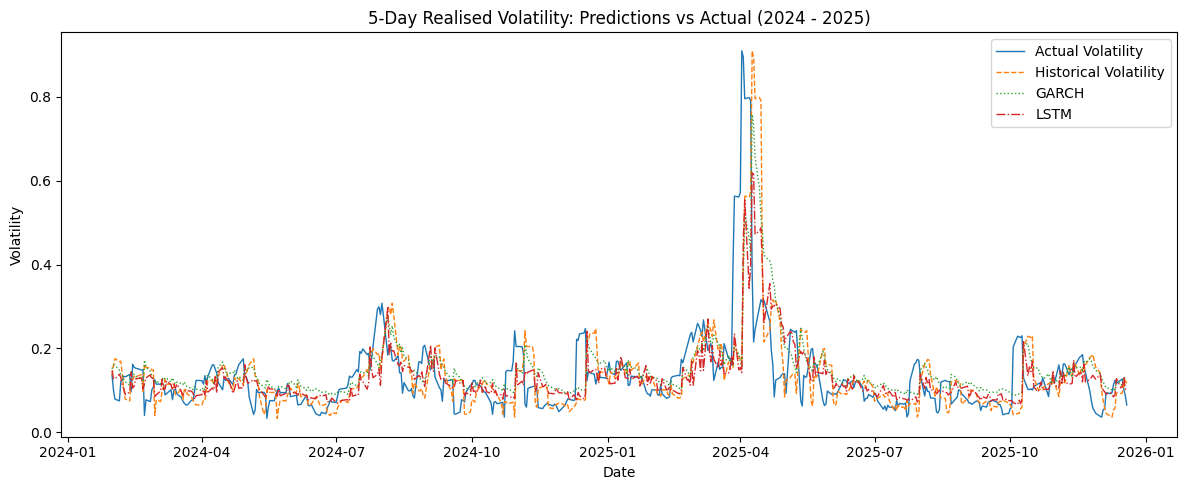

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x_axis, actual_vol, label="Actual Volatility", linewidth=1)
ax.plot(x_axis, hv_predictions, label="Historical Volatility", linewidth=1, linestyle="--")
ax.plot(x_axis, garch_predictions, label="GARCH", linewidth=1, linestyle=":")
ax.plot(x_axis, unnormalised_predictions, label="LSTM", linewidth=1, linestyle="-.")

ax.set_title("5-Day Realised Volatility: Predictions vs Actual (2024 - 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend()

plt.tight_layout()
plt.show()

### Forecast Error plot

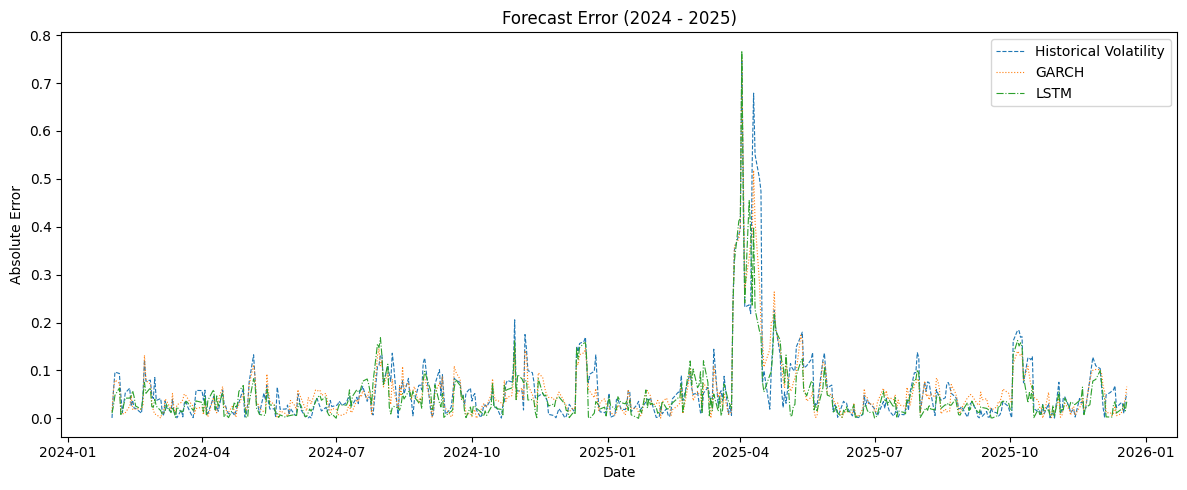

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x_axis, abs(hv_predictions - actual_vol), label="Historical Volatility", linewidth=0.8, linestyle="--")
ax.plot(x_axis, abs(garch_predictions - actual_vol), label="GARCH", linewidth=0.8, linestyle=":")
ax.plot(x_axis, abs(unnormalised_predictions - unnormalised_actual), label="LSTM", linewidth=0.8, linestyle="-.")

ax.set_title("Forecast Error (2024 - 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Error")
ax.legend()

plt.tight_layout()
plt.show()